In [1]:
# Kwant models quantum transport by creating a scattering region with leads - an infinite, translationally invariant system. 
# This code implements a Cylinder with radius = R with leads, focusing on the region of finite length L. 
# More details about the Kwant implementation of the BHZ model in the Kwant Documentation section 2.10.5

# Imports
import kwant
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Definition of the BHZ model
hamiltonian = """
C * identity(4) - M * kron(sigma_0, sigma_z)
- B * (k_x**2 + k_y**2) * kron(sigma_0, sigma_z)
- D * (k_x**2 + k_y**2) * kron(sigma_0, sigma_0)
+ A * k_x * kron(sigma_z, sigma_x)
- A * k_y * kron(sigma_0, sigma_y)
"""

# Discretising with lattice spacing = 1
a = 1
template = kwant.continuum.discretize(hamiltonian, grid=a)

# Define the shape of the system, with leads to connect the left and right edges
radius = 30  # Cylinder radius
L = 200      # Cylinder length

def cylinder_shape(site):
    x, y = site.pos
    return (y**2 < radius**2 and 0 <= x < L)

def lead_cylinder_shape(site):
    x, y = site.pos
    return (y**2 < radius**2)

# Building the system with Kwant.
syst = kwant.Builder()
syst.fill(template, cylinder_shape, (0, 0))
lead = kwant.Builder(kwant.TranslationalSymmetry([-a, 0])) #translational symmetry
lead.fill(template, lead_cylinder_shape, (0, 0))
syst.attach_lead(lead)
syst.attach_lead(lead.reversed())
syst = syst.finalized()

# Setting model parameters. Using simple values, expecting a QSH state for M<0 and a trivial phase for M>0.
# Note that the HgTe well with width = 7 nm has the parameters: 
# params = dict(A=3.645, B=-70.6, C=0, D=-53.2, M=-0.01) 
# units: A = nm eV, B=C=D nm^2 eV, M = eV.
# These values are found in New J. Phys. 12 065012 (2010).

params = dict(A=1, B=1, C=0, D=0, M=-0.3) 

# The other plots in the report are made with the following parameters
# params = dict(A=1, B=1, C=0, D=0, M=-0.3) # Topologically trivial case
# params = dict(A=1, B=1, C=0, D=0, M=0) # Critical case

<Figure size 6000x3600 with 0 Axes>

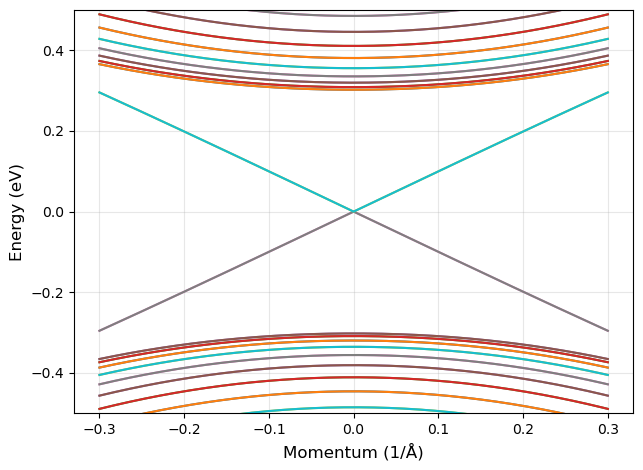

In [3]:
# Plotting bulk band structure with plotter.bands method 
plt.figure(figsize=(10, 6),dpi=300)
kwant.plotter.bands(syst.leads[0], params=params, momenta=np.linspace(-0.3, 0.3, 201), show=False)

# Plotting a small region 
plt.xlabel("Momentum (1/Å)", fontsize=12)
plt.ylabel("Energy (eV)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-0.5,0.5)
plt.savefig("bulk_dispersion_legend.pdf", bbox_inches='tight',dpi=300)

plt.show()

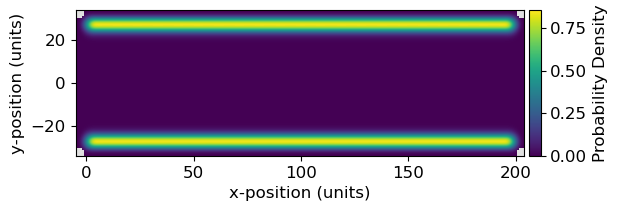

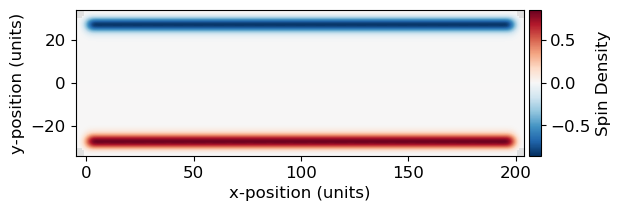

In [4]:
# Plot probability densities to visualise edge transport
# Kwant has the operator.Density method that does this for an open system with leads 
# First, define zero energy to find gap closure

energy = 0.0
wf = kwant.wave_function(syst, energy=energy, params=params)

# Simple edge case check for the wf non-zero
if len(wf(0)) > 0:
    
    # Define density operators
    sigma_z = np.array([[1, 0], [0, -1]])

    # Kwant methods
    prob_density = kwant.operator.Density(syst, np.eye(4))
    spin_density = kwant.operator.Density(syst, np.kron(sigma_z, np.eye(2)))
    
    # Expectation values extracted rom the operator.Density
    wf_sqr = sum(prob_density(psi) for psi in wf(0))
    rho_sz = sum(spin_density(psi) for psi in wf(0))
    
    # Probability density with plotter.density
    fig1, ax1 = plt.subplots(figsize=(6, 2))
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="2.5%", pad=0.05)
    
    kwant.plotter.density(
        syst, wf_sqr, ax=ax1, cmap='viridis', colorbar=False, show=False
    )
    im1 = ax1.images[0]
    cbar1 = fig1.colorbar(im1, cax=cax1)
    cbar1.set_label("Probability Density", fontsize=12)
    ax1.tick_params(labelsize=12)
    cbar1.ax.tick_params(labelsize=12)
    ax1.set_xlabel("x-position (units)", fontsize=12)
    ax1.set_ylabel("y-position (units)", fontsize=12)
    fig1.savefig("probability_density.pdf", dpi=300, bbox_inches='tight')
    
    # Spin probability density with plotter.density
    fig2, ax2 = plt.subplots(figsize=(6, 2))
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="2.5%", pad=0.05)
    
    kwant.plotter.density(
        syst, rho_sz, ax=ax2, cmap='RdBu_r', colorbar=False, show=False
    )
    im2 = ax2.images[0]
    cbar2 = fig2.colorbar(im2, cax=cax2)
    cbar2.set_label("Spin Density", fontsize=12)
    ax2.tick_params(labelsize=12)
    cbar2.ax.tick_params(labelsize=12)
    ax2.set_xlabel("x-position (units)", fontsize=12)
    ax2.set_ylabel("y-position (units)", fontsize=12)
    fig2.savefig("spin_density.pdf", dpi=300, bbox_inches='tight')
    
    plt.show()
else:
    print("No edge states")